In [8]:
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import os

from typing import Callable

from PIL import Image

from jormungandr.utils.image_processors import (
    DetrImageProcessorNoPadBBoxUpdate as DetrImageProcessor,
)
from jormungandr.utils.seed import build_torch_generator, seed_worker

In [12]:
from jormungandr.dataset import create_vod_dataloader, image_processor

In [13]:
train_path = "../data/MOT17/train/MOT17-02-FRCNN/"

train_loader, val_loader = create_vod_dataloader(
    path="../data/", dataset_name="mot17", n_frames=3, batch_size=1, 
)
for i, data in enumerate(train_loader):
    pixel_values, pixel_mask, labels = (
        data["pixel_values"],
        data["pixel_mask"],
        data["labels"],
    )
    # print(f"pixel_values shape: {pixel_values.shape}")
    # print(f"pixel_mask shape:   {pixel_mask.shape}")
    # print(f"Labels image_ids:   {[label['image_id'].item() for label in labels]}")

    break

/home/svernys/Documents/school/master/jormungandr/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


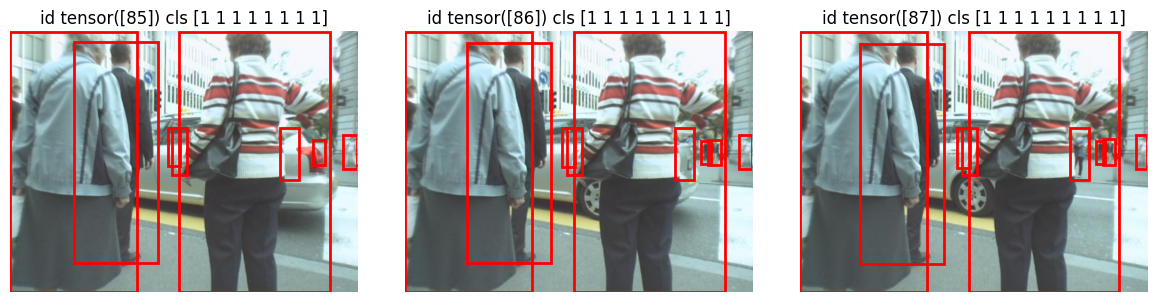

In [14]:
import numpy as np
import torch

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Use the existing batch variable if present, otherwise use data
batch_dict = globals().get("data", globals().get("batch"))

pixel_values = batch_dict["pixel_values"]  # Tensor: (batch_size * n_frames, C, H, W)
labels_list = batch_dict["labels"]  # list of label dicts, length = batch_size * n_frames

# infer batch_size and n_frames
batch_size = getattr(train_loader, "batch_size", None)
if batch_size is None:
    batch_size = 1
total_images = pixel_values.shape[0]
n_frames = total_images // batch_size

# reshape pixel_values -> (batch_size, n_frames, C, H, W)
pv = pixel_values.reshape(batch_size, n_frames, *pixel_values.shape[1:])

# group labels per clip
grouped_labels = [labels_list[i * n_frames : (i + 1) * n_frames] for i in range(batch_size)]

# helper: unnormalize tensor image -> HWC uint8
mean = torch.tensor(image_processor.image_mean, dtype=pixel_values.dtype, device=pixel_values.device).view(-1, 1, 1)
std = torch.tensor(image_processor.image_std, dtype=pixel_values.dtype, device=pixel_values.device).view(-1, 1, 1)


def tensor_to_pil_uint8(img_tensor):
    img = img_tensor.clone()
    img = img * std + mean
    img = img.clamp(0, 1)
    arr = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    return arr


def cxcywh_norm_to_xyxy(boxes_np, h, w):
    # boxes_np: (N, 4) normalized [cx, cy, w, h] (DETR format) -> absolute [x0, y0, x1, y1]
    scaled = boxes_np.copy()
    scaled[:, [0, 2]] *= w
    scaled[:, [1, 3]] *= h
    return np.stack([
        scaled[:, 0] - scaled[:, 2] / 2,
        scaled[:, 1] - scaled[:, 3] / 2,
        scaled[:, 0] + scaled[:, 2] / 2,
        scaled[:, 1] + scaled[:, 3] / 2,
    ], axis=1)


def xywh_to_xyxy(boxes):
    boxes = np.array(boxes, dtype=float)
    return np.stack([boxes[:, 0], boxes[:, 1], boxes[:, 0] + boxes[:, 2], boxes[:, 1] + boxes[:, 3]], axis=1)


# plotting grid
fig, axes = plt.subplots(batch_size, n_frames, figsize=(4 * n_frames, 3 * max(1, batch_size)))
if batch_size == 1:
    axes = np.expand_dims(axes, 0)
if n_frames == 1:
    axes = np.expand_dims(axes, -1)

for b in range(batch_size):
    for f in range(n_frames):
        ax = axes[b, f]
        img_arr = tensor_to_pil_uint8(pv[b, f])
        h_img, w_img = img_arr.shape[:2]
        ax.imshow(img_arr)
        ax.axis("off")

        lbl = grouped_labels[b][f]

        # Extract boxes — DETR processor stores them under "boxes" as normalized cxcywh
        if "boxes" in lbl:
            boxes_np = lbl["boxes"]
            if isinstance(boxes_np, torch.Tensor):
                boxes_np = boxes_np.cpu().numpy()
            else:
                boxes_np = np.array(boxes_np)

            if boxes_np.ndim == 2 and boxes_np.shape[1] == 4:
                boxes_xyxy = cxcywh_norm_to_xyxy(boxes_np, h_img, w_img)
            else:
                boxes_xyxy = boxes_np

        elif "annotations" in lbl and isinstance(lbl["annotations"], (list, tuple)):
            # Raw COCO annotations: bbox is absolute [x, y, w, h]
            bxs = [np.array(ann["bbox"], dtype=float) for ann in lbl["annotations"] if "bbox" in ann]
            if bxs:
                boxes_xyxy = xywh_to_xyxy(np.stack(bxs, axis=0))
            else:
                ax.set_title(f"clip {b} frame {f} - id {lbl.get('image_id', '')}")
                continue
        else:
            ax.set_title(f"clip {b} frame {f} - id {lbl.get('image_id', '')}")
            continue

        for bx in boxes_xyxy:
            x0, y0, x1, y1 = bx
            rect = patches.Rectangle((x0, y0), x1 - x0, y1 - y0, linewidth=2, edgecolor="red", facecolor="none")
            ax.add_patch(rect)

        cls = lbl.get("class_labels", lbl.get("category", None))
        if isinstance(cls, torch.Tensor):
            cls = cls.cpu().numpy()
        if cls is not None:
            ax.set_title(f"id {lbl.get('image_id', '')} cls {cls}")
        else:
            ax.set_title(f"id {lbl.get('image_id', '')}")

plt.tight_layout()
plt.show()